## Exploratory Data Analysis (EDA)

In this stage, the processed dataset will be explored to understand the distribution of classical musical works and evaluate the quality of the engineered features.

The main goals of this analysis are to identify patterns in the dataset, detect potential issues, and gain insights that can guide the development of the recommendation system.

The insights obtained from EDA will be used to validate the engineered features and inform the design of the content-based recommendation model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
df = pd.read_csv(Path('../data/processed/classical_music_feature_engineered.csv'))

In [3]:
df.head()

,title,subtitle,popular,recommended,work_id,genre,composer_id,composer_name,birth,death,epoch,title_subtitle,form,extended_genre,instrumentation,mode,tempo_marking
0,China Gates,NaN,1,1,16893,Keyboard,149,John Adams,1947,NaN,21st Century,China Gates,NaN,Keyboard,Piano,NaN,NaN
1,Doctor Atomic Symphony,NaN,0,1,16878,Orchestral,149,John Adams,1947,NaN,21st Century,Doctor Atomic Symphony,Symphony,Orchestral,Orchestra,NaN,NaN
2,Harmonielehre,NaN,1,1,16875,Orchestral,149,John Adams,1947,NaN,21st Century,Harmonielehre,NaN,Orchestral,Orchestra,NaN,NaN
3,Nixon in China,Opera,1,1,16890,Stage,149,John Adams,1947,NaN,21st Century,Nixon in China Opera,NaN,Opera,"Voice, Chorus, Orchestra",NaN,NaN
4,Short Ride in a Fast Machine,NaN,1,1,16896,Orchestral,149,John Adams,1947,NaN,21st Century,Short Ride in a Fast Machine,NaN,Orchestral,Orchestra,NaN,NaN


### Dataset Overview

* How many musical works and features are available after preprocessing?
* What are the data types of the features?
* Are there any duplicated records or unexpected values?


In [4]:
df.shape

(13014, 17)

In [5]:
df.columns

Index(['title', 'subtitle', 'popular', 'recommended', 'work_id', 'genre',
       'composer_id', 'composer_name', 'birth', 'death', 'epoch',
       'title_subtitle', 'form', 'extended_genre', 'instrumentation', 'mode',
       'tempo_marking'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13014 entries, 0 to 13013
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            13014 non-null  str    
 1   subtitle         1288 non-null   str    
 2   popular          13014 non-null  int64  
 3   recommended      13014 non-null  int64  
 4   work_id          13014 non-null  int64  
 5   genre            13014 non-null  str    
 6   composer_id      13014 non-null  int64  
 7   composer_name    13014 non-null  str    
 8   birth            13014 non-null  int64  
 9   death            12747 non-null  float64
 10  epoch            13014 non-null  str    
 11  title_subtitle   13014 non-null  str    
 12  form             4901 non-null   str    
 13  extended_genre   13014 non-null  str    
 14  instrumentation  12746 non-null  str    
 15  mode             3597 non-null   str    
 16  tempo_marking    204 non-null    str    
dtypes: float64(1), int64(5)

In [7]:
df.describe()

,popular,recommended,work_id,composer_id,birth,death
count,13014.000000,13014.000000,13014.000000,13014.00000,13014.000000,12747.000000
mean,0.021592,0.059244,14839.250807,127.75972,1768.903028,1829.158547
std,0.145353,0.236090,8105.524462,63.27243,115.710233,116.033986
min,0.000000,0.000000,24.000000,2.00000,1135.000000,1201.000000
25%,0.000000,0.000000,7936.250000,82.00000,1685.000000,1750.000000
50%,0.000000,0.000000,15158.500000,129.00000,1797.000000,1828.000000
75%,0.000000,0.000000,22149.750000,188.00000,1865.000000,1934.000000
max,1.000000,1.000000,28122.000000,220.00000,1947.000000,2016.000000


In [8]:
df.describe(include='string')

,title,subtitle,genre,composer_name,epoch,title_subtitle,form,extended_genre,instrumentation,mode,tempo_marking
count,13014,1288,13014,13014,13014,13014,4901,13014,12746,3597,204
unique,12887,219,5,77,10,12899,40,21,197,3,9
top,Violin Concerto,Opera,Vocal,Johann Sebastian Bach,Baroque,Violin Concerto,Sonata,Vocal,Voice,Major,Andante
freq,6,335,5252,981,3005,6,1200,3850,3382,2393,52


In [9]:
df.duplicated().sum()

np.int64(0)

### Missing Value Analysis

- How much missing information exists for each feature?
- Which features are most complete and which require more attention?
- Are missing values caused by unavailable metadata or extraction limitations?

In [10]:
df.isna().sum().sort_values(ascending=False)

tempo_marking      12810
subtitle           11726
mode                9417
form                8113
instrumentation      268
death                267
title                  0
recommended            0
popular                0
birth                  0
composer_name          0
composer_id            0
genre                  0
work_id                0
epoch                  0
title_subtitle         0
extended_genre         0
dtype: int64

In [11]:
df.isna().mean().sort_values(ascending=False)

tempo_marking      0.984325
subtitle           0.901030
mode               0.723605
form               0.623406
instrumentation    0.020593
death              0.020516
title              0.000000
recommended        0.000000
popular            0.000000
birth              0.000000
composer_name      0.000000
composer_id        0.000000
genre              0.000000
work_id            0.000000
epoch              0.000000
title_subtitle     0.000000
extended_genre     0.000000
dtype: float64

#### Missing Value Insight

The high percentage of missing values in some engineered features does not necessarily indicate poor data quality. These features were extracted only when the corresponding information was explicitly available in the metadata. Therefore, missing values represent unavailable metadata rather than errors introduced during preprocessing.

### Composer Analysis

* Which composers are most represented in the dataset?
* Is the dataset balanced across composers, or dominated by a small number of composers?


In [12]:
df['composer_name'].value_counts()

composer_name
Johann Sebastian Bach    981
Franz Schubert           862
Franz Joseph Haydn       618
Antonio Vivaldi          597
Domenico Scarlatti       588
                        ... 
Pierre Boulez             27
Steve Reich               26
Gustav Mahler             24
Léonin                    12
Pérotin                    9
Name: count, Length: 77, dtype: int64

In [13]:
top_20_composers = df['composer_name'].value_counts().head(20)

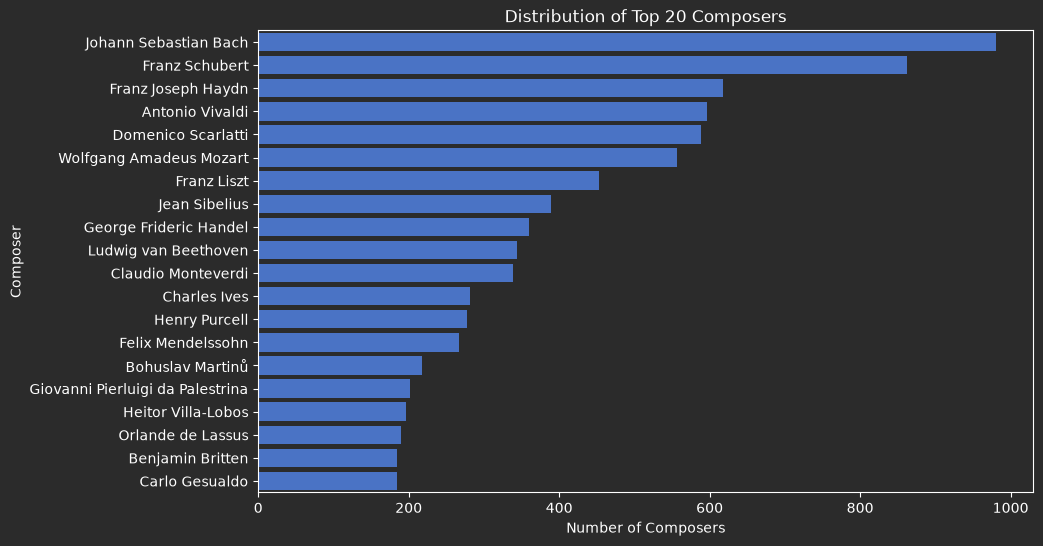

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_20_composers.values,
    y=top_20_composers.index,
)
plt.title('Distribution of Top 20 Composers')
plt.xlabel('Number of Composers')
plt.ylabel('Composer')
plt.show()

#### Composer Distribution Insight

The dataset is not evenly distributed across composers. A small number of composers contribute a large proportion of the works, while many composers are represented by relatively few compositions. This imbalance should be considered when interpreting recommendation results, as composers with larger catalogs are more likely to appear in the recommendations.

### Era Analysis

* How are musical works distributed across different eras?
* Which periods are most represented in the dataset?


In [15]:
df['epoch'].value_counts()

epoch
Baroque           3005
Romantic          2309
20th Century      2214
Early Romantic    1364
Classical         1205
Renaissance       1175
Late Romantic     1139
Post-War           479
Medieval            97
21st Century        27
Name: count, dtype: int64

In [16]:
epoch_order = ['Medieval', 'Renaissance', 'Baroque', 'Classical', 'Early Romantic', 'Romantic', 'Late Romantic',
               '20th Century', 'Post-War', '21st Century']

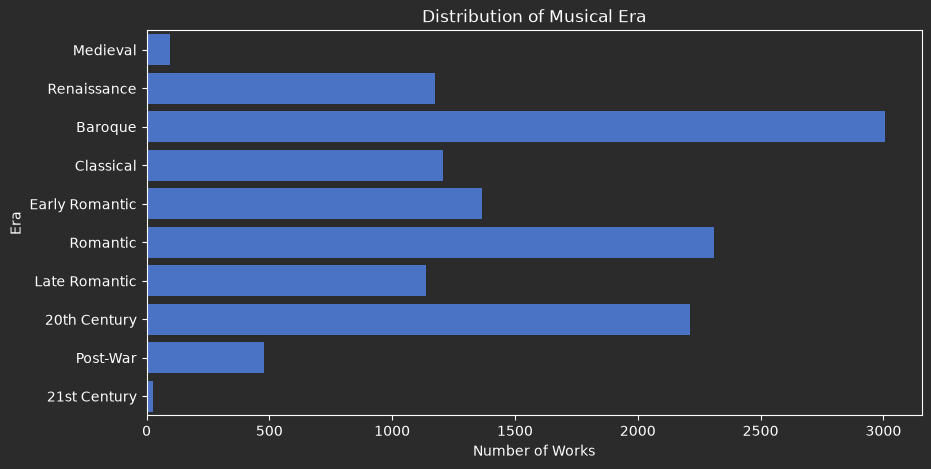

In [17]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    y='epoch',
    order=epoch_order
)
plt.title('Distribution of Musical Era')
plt.xlabel('Number of Works')
plt.ylabel('Era')
plt.show()

### Distribution of Musical Era Insight

The dataset covers musical works from the Medieval period to the 21st Century. The largest portion of the dataset belongs to the Baroque era, followed by the Romantic and 20th Century periods. In contrast, the Medieval and 21st Century eras are represented by relatively few works. This distribution indicates that the dataset is not balanced across musical periods, with a stronger emphasis on Baroque and Romantic repertoire.

### Form Analysis

* Which musical forms are most common?
* What percentage of works have an identifiable form?
* Are some forms underrepresented?


In [18]:
df['form'].value_counts()

form
Sonata         1200
Concerto        746
Symphony        500
Quartet         383
Trio            247
Suite           241
Fugue           188
Variations      160
Prelude         114
Overture        102
Waltz            90
Fantasy          80
Minuet           77
Duet             70
Romance          68
Quintet          63
Serenade         51
Rondo            49
Scherzo          46
Canon            44
Capriccio        37
Polonaise        33
Mazurka          31
Ballade          29
Ordre            28
Nocturne         27
Impromptu        25
Lullaby          24
Polka            24
Toccata          23
Partita          19
Rhapsody         16
Etude            14
Chaconne         13
Intermezzo       11
Passacaglia      10
Sarabande         9
Invention         4
Interlude         3
Arabesque         2
Name: count, dtype: int64

In [19]:
df['form'].isna().mean()

np.float64(0.6234055632395882)

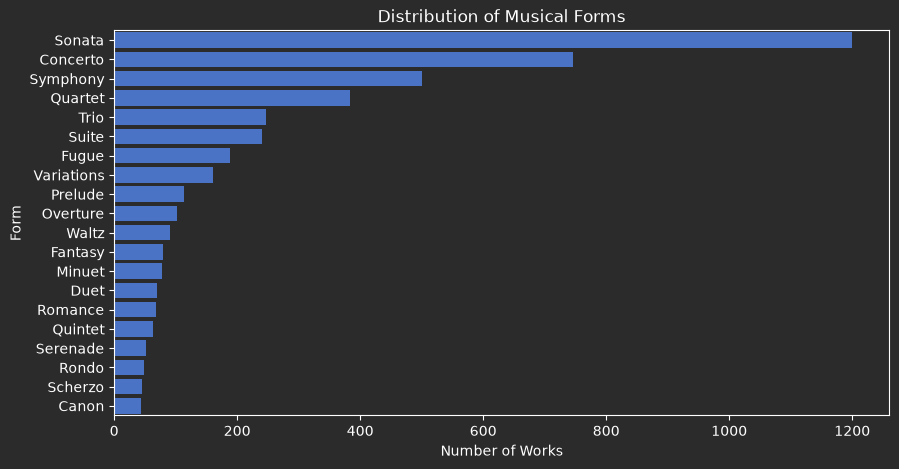

In [20]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    y='form',
    order=df['form'].value_counts().head(20).index
)
plt.title('Distribution of Musical Forms')
plt.xlabel('Number of Works')
plt.ylabel('Form')
plt.show()

### Form Distribution Insight

In the dataset 62% of musical forms has an identified musical form.

The distribution of musical forms shows a strong imbalance across the dataset. **Sonata** is the most frequently represented form, followed by **Concerto**, **Symphony**, and **Quartet**.

While large-scale classical forms such as Sonata, Concerto, and Symphony have substantial representation, many forms appear only in a small number of works. Forms such as Arabesque, Interlude, Invention, and Passacaglia have limited examples in the dataset.

This imbalance should be considered when using form as a feature in the recommendation system, as rare forms may have less influence during similarity calculation compared to frequently occurring forms.


### Extended Genre Analysis

* Which genres and work types are most frequent?
* How does the extended genre feature improve the original genre information?


In [21]:
df['genre'].value_counts()

genre
Vocal         5252
Keyboard      3069
Orchestral    2117
Chamber       1903
Stage          673
Name: count, dtype: int64

In [22]:
df['extended_genre'].value_counts()

extended_genre
Vocal               3850
Keyboard            2862
Orchestral          1998
Chamber             1843
Song                 776
Opera                354
Aria                 328
Cantata              266
Stage                229
Lied                 130
Ballet                98
Incidental Music      55
Mass                  46
Lieder                36
Oratorio              29
Musical               29
Salve Regina          28
Choral                26
Passion               16
Stabat Mater          14
Operetta               1
Name: count, dtype: int64

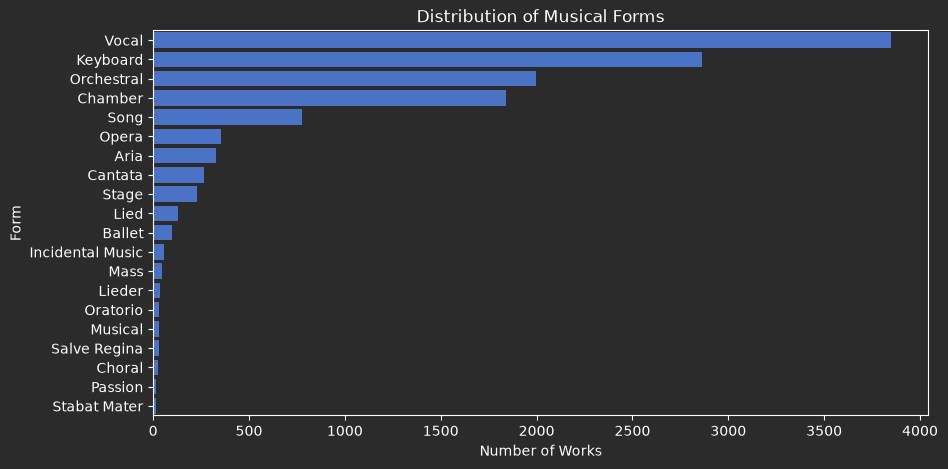

In [23]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    y='extended_genre',
    order=df['extended_genre'].value_counts().head(20).index
)
plt.title('Distribution of Musical Forms')
plt.xlabel('Number of Works')
plt.ylabel('Form')
plt.show()

## Genre Distribution Insight

The original dataset contains five broad genre categories: **Vocal**, **Keyboard**, **Orchestral**, **Chamber**, and **Stage**. Vocal works represent the largest category, followed by Keyboard and Orchestral works.

To obtain a more detailed representation of musical works, an **extended genre** feature was created by extracting additional work types from titles and subtitles. This feature provides more specific categories such as **Opera**, **Aria**, **Cantata**, **Song**, **Lied**, **Ballet**, **Mass**, and **Oratorio**.

The extended genre feature reveals additional structure that was not captured by the original genre labels. However, the distribution remains imbalanced, with broad categories such as Vocal, Keyboard, and Orchestral having much higher representation than less frequent categories such as Passion, Stabat Mater, and Operetta.


### Instrument / Performing Forces Analysis

* Which instruments or ensembles are most common?
* Are certain instruments associated with specific genres or forms?

In [24]:
instrument_count = df['instrumentation'].dropna().str.split(',').explode().str.strip().value_counts()
instrument_count

instrumentation
Voice              4800
Piano              4410
Orchestra          3202
Chorus             1296
ChamberEnsemble     814
Violin              807
Cello               307
Flute               199
Strings             183
Oboe                167
Viola               121
Clarinet            120
Harpsichord          58
Percussion           43
Winds                37
Brass                28
Guitar               25
Contrabass            2
Name: count, dtype: int64

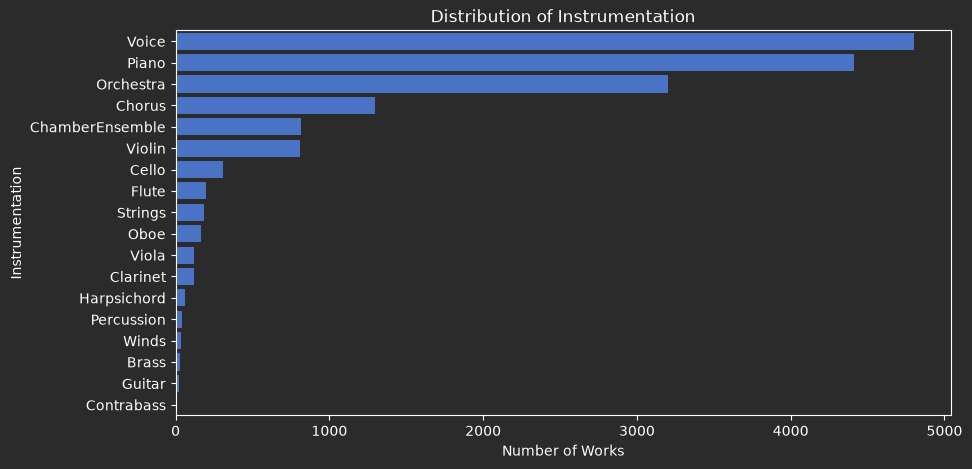

In [25]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=instrument_count.values,
    y=instrument_count.index,
)
plt.title('Distribution of Instrumentation')
plt.xlabel('Number of Works')
plt.ylabel('Instrumentation')
plt.show()

### Instrument Distribution Analysis

The distribution of performing forces is highly imbalanced across the dataset. **Voice** is the most common category, followed by **Piano** and **Orchestra**. These results are consistent with the large number of vocal works, keyboard compositions, and orchestral pieces present in the collection.

Among individual instruments, **Violin** and **Cello** are the most frequently represented, reflecting their central role in the classical repertoire. Woodwind instruments such as **Flute**, **Oboe**, and **Clarinet** also appear regularly, while instruments including **Harpsichord**, **Guitar**, **Brass**, and **Contrabass** are represented by relatively few works.

Unlike the original metadata, which often described only broad categories, the extracted instrument feature provides more detailed information about the performing forces of each work. This additional information is expected to improve similarity estimation in the content-based recommendation system by distinguishing works written for different instruments or ensembles.


### Mode and Tempo Analysis

* What is the distribution of musical modes (e.g., Major, Minor)?
* Which tempo markings appear most frequently?

In [26]:
df['mode'].value_counts()

mode
Major       2393
Minor       1202
Phrygian       2
Name: count, dtype: int64

In [27]:
df['tempo_marking'].value_counts()

tempo_marking
Andante       52
Allegro       46
Adagio        39
Allegretto    32
Moderato       9
Presto         9
Lento          8
Largo          6
Vivace         3
Name: count, dtype: int64

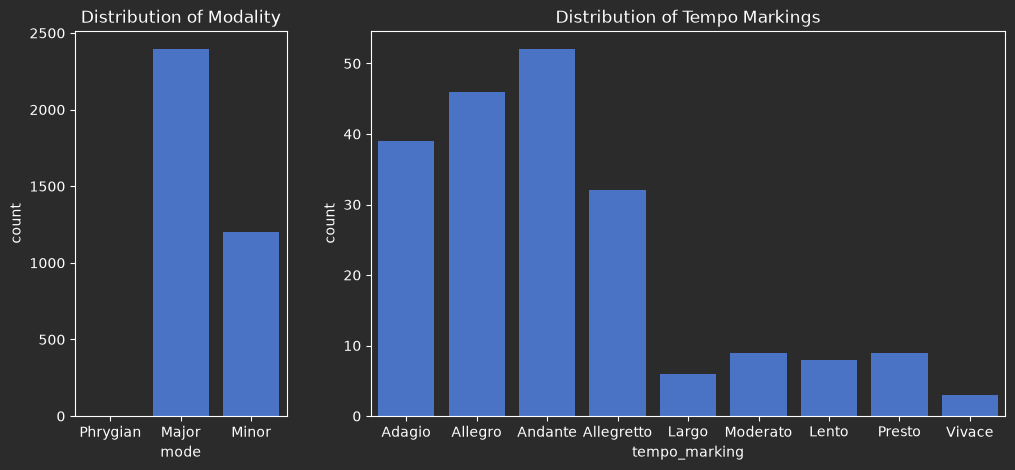

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 3]})
sns.countplot(
    data=df,
    x = df['mode'],
    ax=axes[0],
)
sns.countplot(
    data=df,
    x = df['tempo_marking'],
    ax=axes[1],
)
axes[0].set_title('Distribution of Modality')
axes[1].set_title('Distribution of Tempo Markings')
plt.show()

### Feature Relationships

* Are certain forms more common in specific eras?
* Are certain genres strongly associated with particular instruments?

#### Are certain forms more common in specific eras?

In [29]:
epoch_era = pd.crosstab(df['epoch'], df['form'])

In [30]:
epoch_era_df = pd.DataFrame({
    'Most Common Form': epoch_era.idxmax(axis=1),
    'Count': epoch_era.max(axis=1)
}).reindex(epoch_order)
epoch_era_df

,Most Common Form,Count
epoch,,
Medieval,NaN,NaN
Renaissance,Duet,7.0
Baroque,Sonata,740.0
Classical,Symphony,166.0
Early Romantic,Sonata,91.0
Romantic,Symphony,109.0
Late Romantic,Symphony,45.0
20th Century,Quartet,102.0
Post-War,Concerto,41.0


#### Are certain genres strongly associated with particular instruments?

In [31]:
temp = df.copy()
temp['instrumentation'] = temp['instrumentation'].str.split(',')
temp = temp.explode('instrumentation').reset_index(drop=True)
temp['instrumentation'] = temp['instrumentation'].str.strip()

In [32]:
temp['instrumentation'].head()

0        Piano
1    Orchestra
2    Orchestra
3        Voice
4       Chorus
Name: instrumentation, dtype: str

In [33]:
genre_instrumentation = pd.crosstab(temp['extended_genre'], temp['instrumentation'])

In [34]:
pd.DataFrame({
    'Most Common Instrument': genre_instrumentation.idxmax(axis=1),
    'Count': genre_instrumentation.max(axis=1)
})

,Most Common Instrument,Count
extended_genre,,
Aria,Voice,188
Ballet,Orchestra,89
Cantata,Chorus,245
Chamber,ChamberEnsemble,814
Choral,Chorus,24
Incidental Music,Orchestra,6
Keyboard,Piano,2825
Lied,Piano,127
Lieder,Piano,28


## Feature Analysis Summary

The extracted features reveal meaningful patterns that can help measure similarity between classical music works.

The analysis shows that historical periods have distinct characteristics. Different eras are associated with different dominant musical forms, such as Sonata during the Baroque period, Symphony during the Classical and Romantic periods, and Quartet in later periods.

The extended genre and performing forces features provide additional information beyond the original metadata. For example, genres such as Opera, Oratorio, and Cantata are strongly associated with vocal and orchestral forces, while forms such as Quartet and Trio are linked to chamber ensembles.

Although some features, such as tempo markings, contain a high amount of missing data and should be used with caution, the combination of available metadata features captures meaningful aspects of musical style, structure, and instrumentation.

These findings support the use of the extracted features as inputs for a content-based recommendation system.
